# Figure 7 — SLAP2 glutamate column (panels C, G, K)

Renders the **SLAP2 glutamate** column of Figure 7 of the data-release paper.

Figure 7 is a 4-column x 3-row grid:

| | Neuropixels | Mesoscope | **SLAP2 glutamate** | SLAP2 voltage |
|---|---|---|---|---|
| **row 1** — example 2D projection, single source, trace + events | A | B | **C** | D |
| **row 2** — measure of signal and noise on traces, class definitions | E | F | **G** | H |
| **row 3** — distribution of classes across context / neurons | I | J | **K** | L |

Panel C shows one example session (`sub-794237`, 2025-05-08, DANDI 001424: iGluSnFR4f glutamate
imaging at 200 Hz of proximal (DMD1) and apical (DMD2) dendrites of one neuron). Panels G and K
use **every session in the archive** — 20 sessions, 8 mice, 2,540 synapses — through the tables
written by `code/data-access/slap2_glutamate_qc_batch.py`.

The QC scheme is event-based and mirrors the mesoscope ophys QC agreed in
[discussion #156](https://github.com/AllenNeuralDynamics/openscope-community-predictive-processing/discussions/156):

1. **detect** events as local maxima of the matched-filtered ΔF/F above 3 SD of its noise
   (noise SD from the below-median half of the trace, which glutamate release cannot reach);
2. **measure** each event's amplitude on the raw ΔF/F — peak minus local baseline — in SD of the
   raw-trace noise, and bin it as < 2 SD, 2–4 SD or > 4 SD;
3. **classify** each synapse by the fractions of its events in the three bins: k-means (k = 3) on
   those fractions, classes named Low / Intermediate / High SNR by the > 4 SD fraction of the centroid.

All computation lives in `code/data-access/` (`slap2_glutamate_qc_events.py`, `slap2_glutamate_qc_batch.py`,
`slap2_glutamate_figure7_panels.py`), so this notebook and the scripts cannot drift apart.

### Imports

In [1]:
from pathlib import Path
import sys, warnings

warnings.filterwarnings("ignore")

import pandas as pd
from IPython.display import Image, display

REPO = Path.cwd().resolve().parents[1]          # docs/notebooks -> repo root
sys.path.insert(0, str(REPO / "code" / "data-access"))

import slap2_glutamate_qc_events as qc
import slap2_glutamate_figure7_panels as panels

print("SILo matched-filter tau :", qc.TAU_IGLUSNFR4F_S, "s")
print("detection floor         :", qc.SD_DETECT, "SD of the filtered-trace noise")
print("large-event boundary    :", qc.SD_LARGE, "SD of the raw-trace noise (same as mesoscope, #156)")

SILo matched-filter tau : 0.02 s
detection floor         : 3.0 SD of the filtered-trace noise
large-event boundary    : 4.0 SD of the raw-trace noise (same as mesoscope, #156)


### The example session

Same DANDI asset as `pilot_analysis_rfs.ipynb` and `pilot_analysis_signal_qc.ipynb`, so results line
up with the RF and evoked-SNR analyses. The file is ~2.8 GB and is downloaded once into this folder
(do not commit it).

In [2]:
dandiset_id    = "001424"
dandi_filepath = "sub-794237/sub-794237_ses-20250508T145040_image+ophys.nwb"

NWB_PATH = Path(dandi_filepath.split("/")[-1])
OUT_DIR  = Path("plots_figure7_slap2_glutamate")           # archive-wide tables live here already
OUT_DIR.mkdir(exist_ok=True)

if NWB_PATH.exists():
    print(f"Using existing {NWB_PATH} ({NWB_PATH.stat().st_size/1e9:.2f} GB)")
else:
    from dandi import dandiapi, download
    client = dandiapi.DandiAPIClient()
    asset = client.get_dandiset(dandiset_id).get_asset_by_path(dandi_filepath)
    download.download(asset.download_url, output_dir=".")
    print(f"Downloaded {NWB_PATH}")

Using existing sub-794237_ses-20250508T145040_image+ophys.nwb (2.76 GB)


### Step 1 — QC of one session

`qc.compute` walks both DMDs, detects events on every ΔF/F trace, and writes three tables:

| file | contents |
|---|---|
| `slap2_event_metrics.csv` | one row per synapse: event rate, false-positive fraction, 95/50 SNR, event-amplitude composition, quality class (fitted within this session) |
| `slap2_events.csv` | one row per event: time, amplitude, stimulus context (~27 MB, regenerates in ~20 s — do not commit it) |
| `stimulus_contexts.csv` | every stimulus presentation labelled control / oddball standard / oddball deviant / RF mapping / blank |

This is the per-session tool; it is what `slap2_glutamate_qc_batch.py` runs over the whole archive.

In [3]:
qc.compute(NWB_PATH, OUT_DIR)

Layout: dff (glutamate only) · DMDs [1, 2]
Contexts (inferred from orientation statistics):
context
Oddball standard        2446
RF mapping              1470
Control (random ori)    1278
Oddball deviant           81
Blank                     40
standard orientation = 0.000 rad



DMD1: 120 sources, 599588 samples, 200.0 Hz, 3088 s


DMD2: 59 sources, 599588 samples, 200.0 Hz, 3088 s



Per-source metrics (median by DMD):
     event_rate_hz  false_pos_frac  robust_snr  median_event_sd  frac_events_gt4sd
dmd                                                                               
1            1.068           0.006       2.289            3.796              0.461
2            0.972           0.006       2.257            3.735              0.451

Quality classes:
dmd             1   2
quality_class        
High SNR       27  15
Intermediate   42  18
Low SNR        51  26
               event_rate_hz  false_pos_frac  robust_snr  median_event_sd  frac_events_gt4sd
quality_class                                                                               
High SNR               1.392           0.002       2.568            4.137              0.561
Intermediate           0.985           0.006       2.282            3.715              0.492
Low SNR                0.892           0.012       2.181            3.717              0.392

Wrote plots_figure7_slap2_glutamate/ 

### What the metrics mean

| metric | meaning |
|---|---|
| `event_rate_hz` | detected events per second of valid recording |
| `false_pos_frac` | downward peaks of the matched-filtered trace beyond the same 3 SD floor, divided by detections. Release only pushes the trace up, so downward crossings are an **empirical noise null** |
| `robust_snr` | `(P95(ΔF/F) − P50(ΔF/F)) / noise SD` — the portable 95/50 metric proposed in #156 |
| `frac_events_lt2sd`, `frac_events_2_4sd`, `frac_events_gt4sd` | fraction of the synapse's events with raw amplitude < 2, 2–4, > 4 SD of the raw-trace noise — the three features the classes are fitted on |
| `quality_class` | Low SNR / Intermediate / High SNR (k-means on the three fractions); `Excluded (no baseline noise)` for rectified traces that sit at exactly zero for more than half the session |

In [4]:
metrics = pd.read_csv(OUT_DIR / "slap2_event_metrics.csv")
cols = ["event_rate_hz", "false_pos_frac", "robust_snr",
        "frac_events_lt2sd", "frac_events_2_4sd", "frac_events_gt4sd"]
print(f"{len(metrics)} synapses, {int(metrics.n_events.sum()):,} events\n")
print("Median metric by quality class (fitted within this session):")
display(metrics.groupby("quality_class")[cols].median().round(3))
print("Class composition by dendritic compartment (row %):")
display((pd.crosstab(metrics.dmd, metrics.quality_class, normalize="index") * 100).round(1))

179 synapses, 555,949 events

Median metric by quality class (fitted within this session):


,event_rate_hz,false_pos_frac,robust_snr,frac_events_lt2sd,frac_events_2_4sd,frac_events_gt4sd
quality_class,,,,,,
High SNR,1.392,0.002,2.568,0.146,0.298,0.561
Intermediate,0.985,0.006,2.282,0.114,0.388,0.492
Low SNR,0.892,0.012,2.181,0.166,0.441,0.392


Class composition by dendritic compartment (row %):


quality_class,High SNR,Intermediate,Low SNR
dmd,,,
1,22.5,35.0,42.5
2,25.4,30.5,44.1


### Step 2 — the archive-wide tables

`slap2_glutamate_qc_batch.py` runs the same QC over all 20 sessions of DANDI 001424 (one download at a time,
~43 GB in total, ~2 h) and writes, into the same folder:

| file | contents |
|---|---|
| `slap2_metrics_all_sessions.csv` | one row per synapse (2,540), with `quality_class_session` (fitted within its session) and `quality_class` (fitted per acquisition cohort — the label the panels use) |
| `slap2_context_rates_all_sessions.csv` | one row per synapse × stimulus context: events, seconds recorded in that context, rate |
| `slap2_session_summary.csv` | one row per session |

They are committed, so the cells below run without the batch. To regenerate:

```bash
cd code/data-access
python slap2_glutamate_qc_batch.py --output ../../docs/notebooks/plots_figure7_slap2_glutamate --cache /tmp/slap2_cache
python slap2_glutamate_qc_batch.py --output ../../docs/notebooks/plots_figure7_slap2_glutamate --refit-only   # classes only
```

**Why classes are fitted per cohort.** The 12 glutamate-only sessions ship two-sided ΔF/F (about a
quarter of the samples below zero); the 8 glutamate + calcium sessions ship non-negative, NMF-denoised
traces. The two are on different noise scales, so a single k-means over all 20 sessions would mostly
sort synapses by pipeline rather than by signal quality.

In [5]:
m_all   = pd.read_csv(OUT_DIR / "slap2_metrics_all_sessions.csv")
ctx_all = pd.read_csv(OUT_DIR / "slap2_context_rates_all_sessions.csv")
summary = pd.read_csv(OUT_DIR / "slap2_session_summary.csv")

print(f"{len(summary)} sessions, {summary.subject.nunique()} mice, {len(m_all):,} synapses")
display(summary[["subject", "session", "layout", "has_calcium", "n_sources", "duration_s",
                 "median_event_rate_hz", "median_false_pos_frac", "median_robust_snr",
                 "n_low_snr", "n_intermediate", "n_high_snr"]])

20 sessions, 8 mice, 2,540 synapses


,subject,session,layout,has_calcium,n_sources,duration_s,median_event_rate_hz,median_false_pos_frac,median_robust_snr,n_low_snr,n_intermediate,n_high_snr
0,776270,sub-776270_ses-SLAP2-776270-2025-07-02-11-50-06,fluorescence,False,40,3929.4,0.673,0.0000,2.394,12,12,16
1,794237,sub-794237_ses-20250403T103830,dff,False,223,2058.5,1.042,0.0034,2.314,144,59,20
2,794237,sub-794237_ses-20250424T142019,dff,False,157,3086.6,0.845,0.0105,2.163,93,39,25
3,794237,sub-794237_ses-20250508T145040,dff,False,179,3088.4,1.044,0.0061,2.284,84,63,32
4,796630,sub-796630_ses-SLAP2-796630-2025-08-25-14-59-15,fluorescence,False,133,3949.7,0.659,0.0000,2.423,10,66,57
5,796630,sub-796630_ses-SLAP2-796630-2025-08-28-14-25-34,fluorescence,False,119,3950.5,0.721,0.0000,2.475,2,50,67
6,796630,sub-796630_ses-SLAP2-796630-2025-09-26-10-48-22,fluorescence,False,167,3950.5,0.699,0.0000,2.496,3,48,116
7,796630,sub-796630_ses-SLAP2-796630-2025-10-01-14-23-25,fluorescence,False,227,3949.8,0.763,0.0000,2.535,5,87,135
8,801381,sub-801381_ses-SLAP2-801381-2025-06-05-14-57-42,fluorescence,False,131,3020.0,0.815,0.0004,2.585,12,78,41
9,801381,sub-801381_ses-SLAP2-801381-2025-09-26-14-17-56,fluorescence,False,113,3950.5,0.748,0.0000,2.506,10,60,43


### Step 3 — render the panels

Each panel is written as SVG (for the manuscript) and PNG (for display here). Colours are a validated
one-hue ordinal ramp for the ordered classes; the palest step sits below 3:1 on white, so every class
is also named in a legend or direct label.

`load_session_cached` stashes the example session's arrays as `.npz` under `CACHE` so re-rendering
does not re-read the 2.8 GB NWB.

In [6]:
CACHE = Path("/tmp/slap2_session_cache")          # local disk; delete to force a re-read

panels.set_style()
sess = panels.load_session_cached(NWB_PATH, CACHE)
m_ex = m_all[m_all.session == panels.session_id(NWB_PATH)].reset_index(drop=True)
print(f"example session: {len(m_ex)} synapses, cohort classes "
      f"{m_ex.quality_class.value_counts().to_dict()}")

loaded session arrays from /tmp/slap2_session_cache/sub-794237_ses-20250508T145040.npz
example session: 179 synapses, cohort classes {'Low SNR': 84, 'Intermediate': 63, 'High SNR': 32}


#### Panel C — example projection, single synapse, trace with detected events

Both imaging planes are shown: recording proximal (DMD1) and apical (DMD2) dendrites of the same neuron
simultaneously is what defines the SLAP2 prep. SLAP2 samples only user-selected regions, so each plane is
a set of disjoint imaged islands (dashed boxes, with their synapse counts). Footprints are coloured by
quality class; the circled synapse is the one whose trace is shown below.

panel C  → example synapse 9 (DMD1), 5074 events, class High SNR


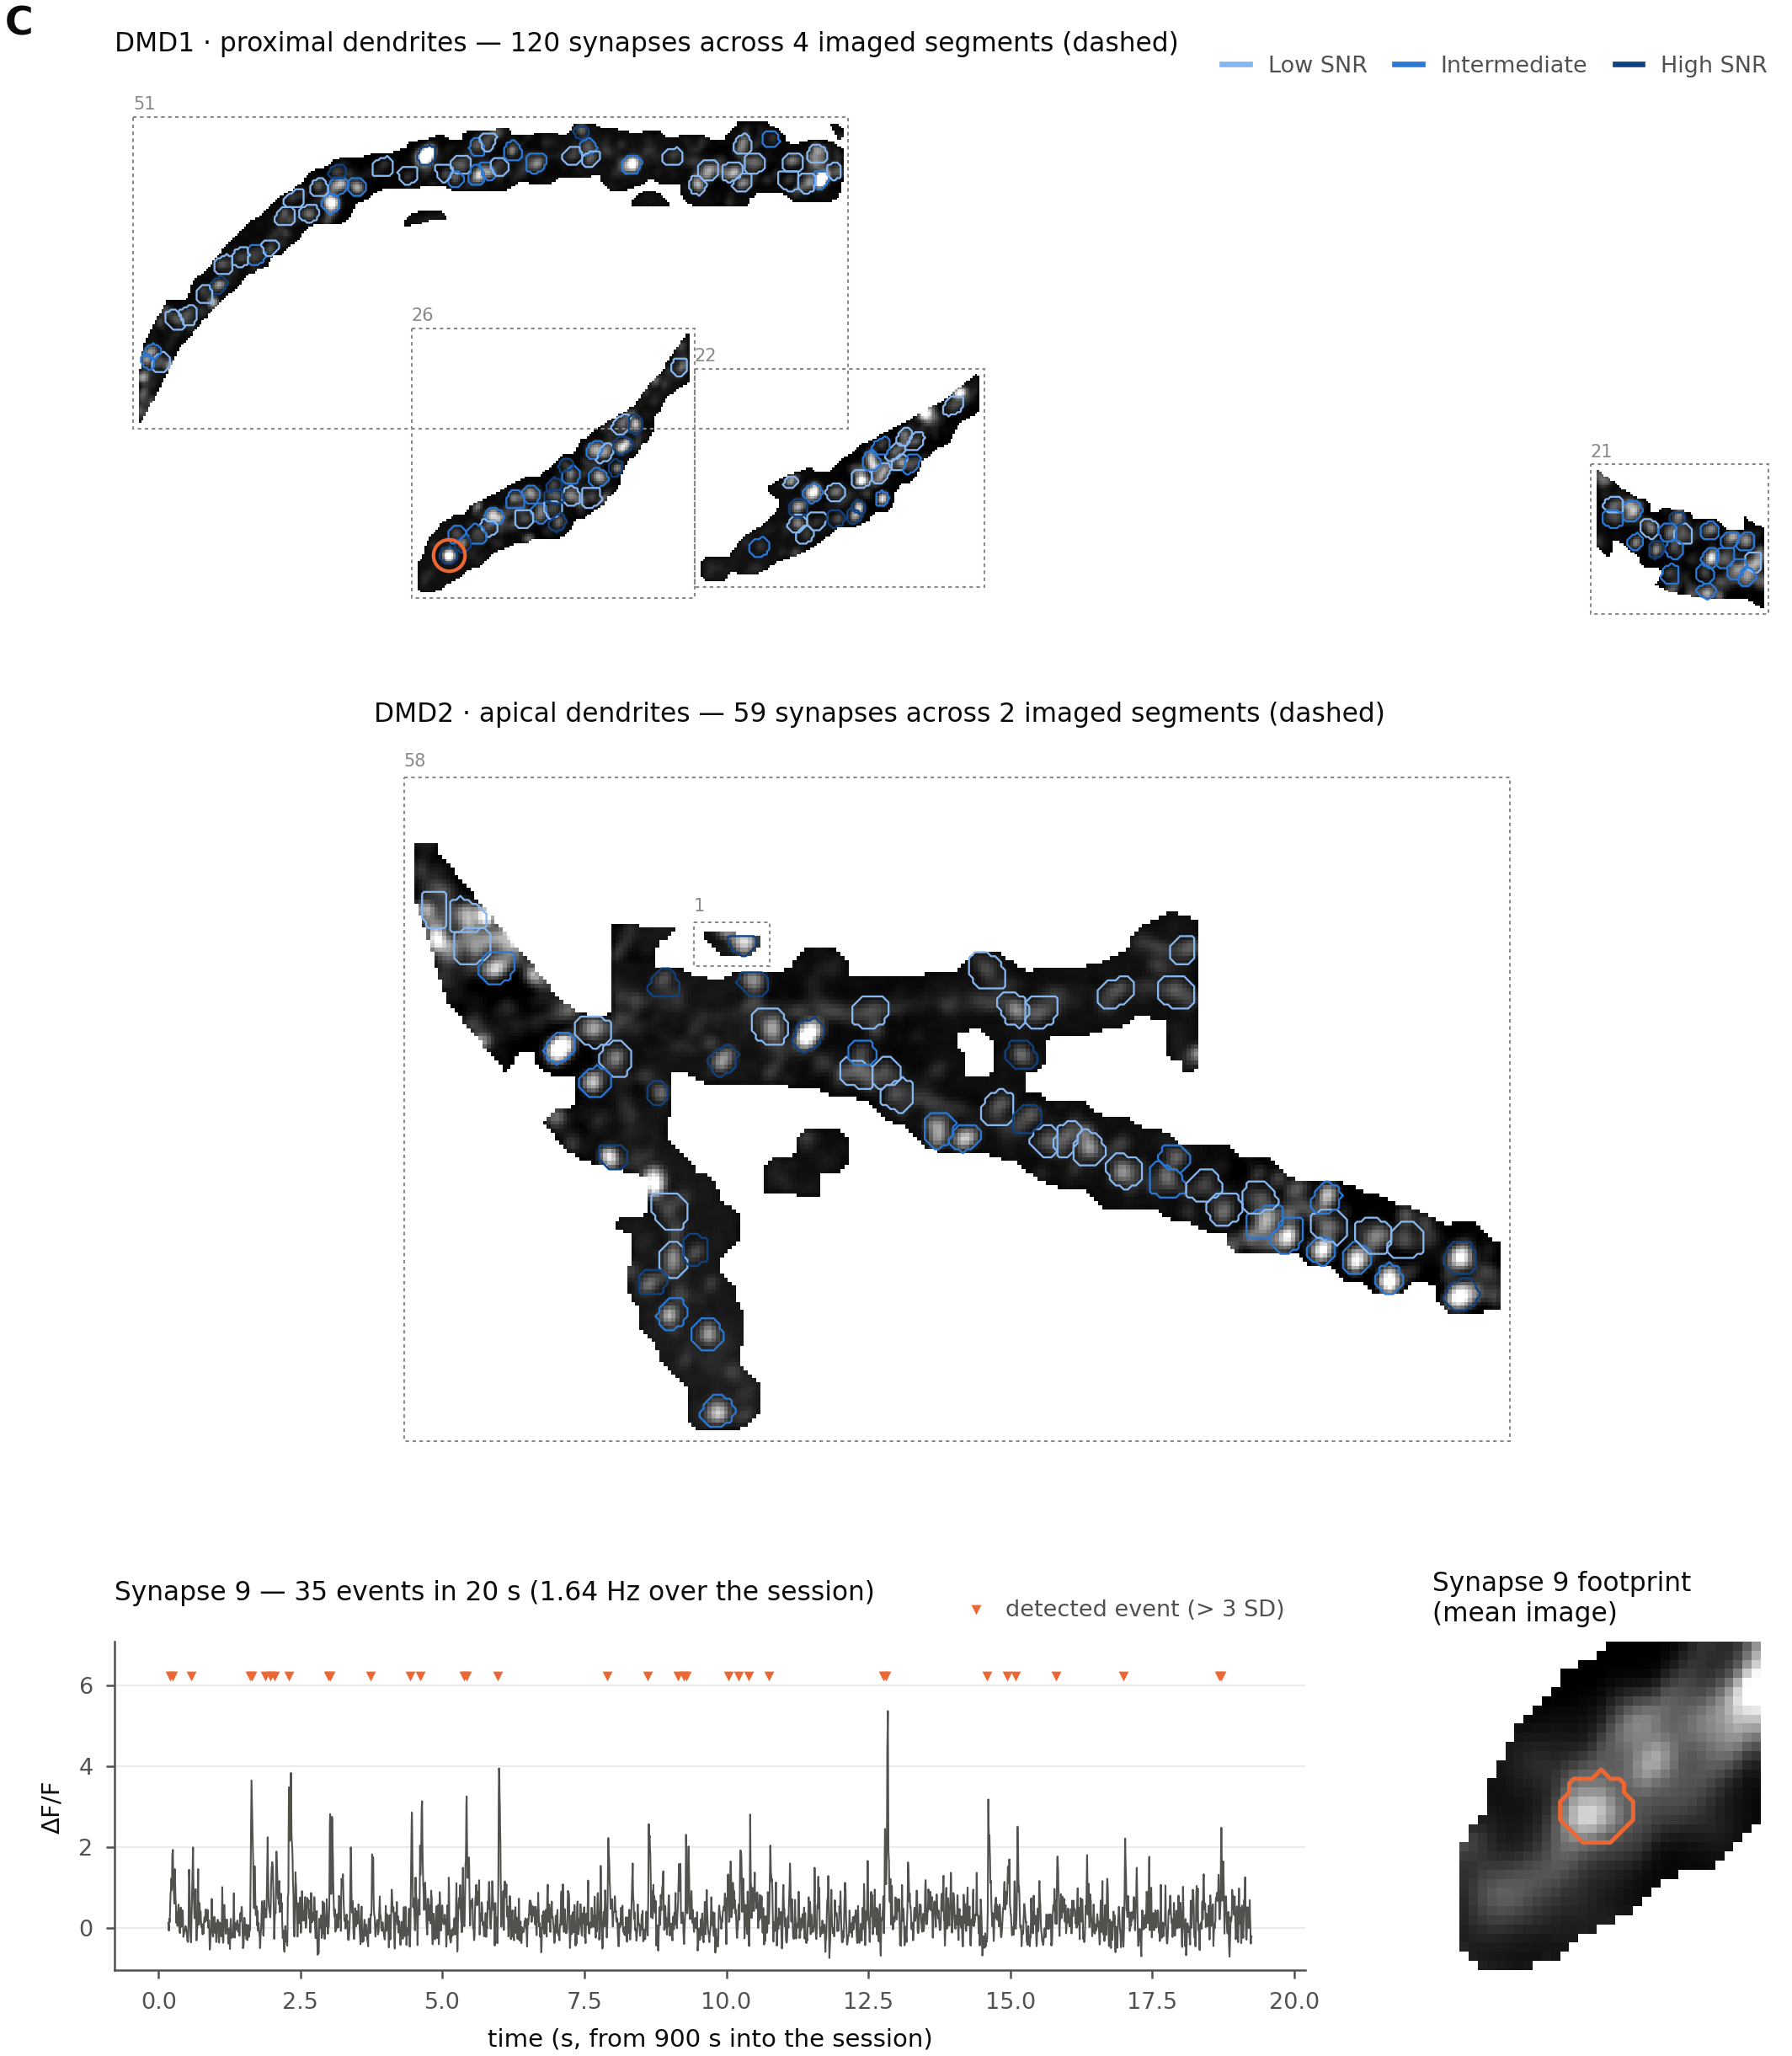

In [7]:
panels.render_panel_c(sess, m_ex, OUT_DIR)
display(Image(str(OUT_DIR / "figure7_panelC_slap2_glutamate.png")))

#### Panel G — measuring signal and noise, and the class definition

Top: the two steps of the measurement on 5 s of the same synapse — detection on the matched-filtered
trace (3 SD), amplitude on the raw trace (brackets, coloured by amplitude bin).
Bottom left: how a synapse gets its class — the amplitude histogram of one representative synapse per
class with its < 2 / 2–4 / > 4 SD fractions. Bottom right: every classified synapse of the archive in
that feature space, one axis per acquisition cohort (rings: the three examples).

panel G  → trace window from 920 s; class examples {'Low SNR': (2, 7), 'Intermediate': (1, 85), 'High SNR': (1, 80)}


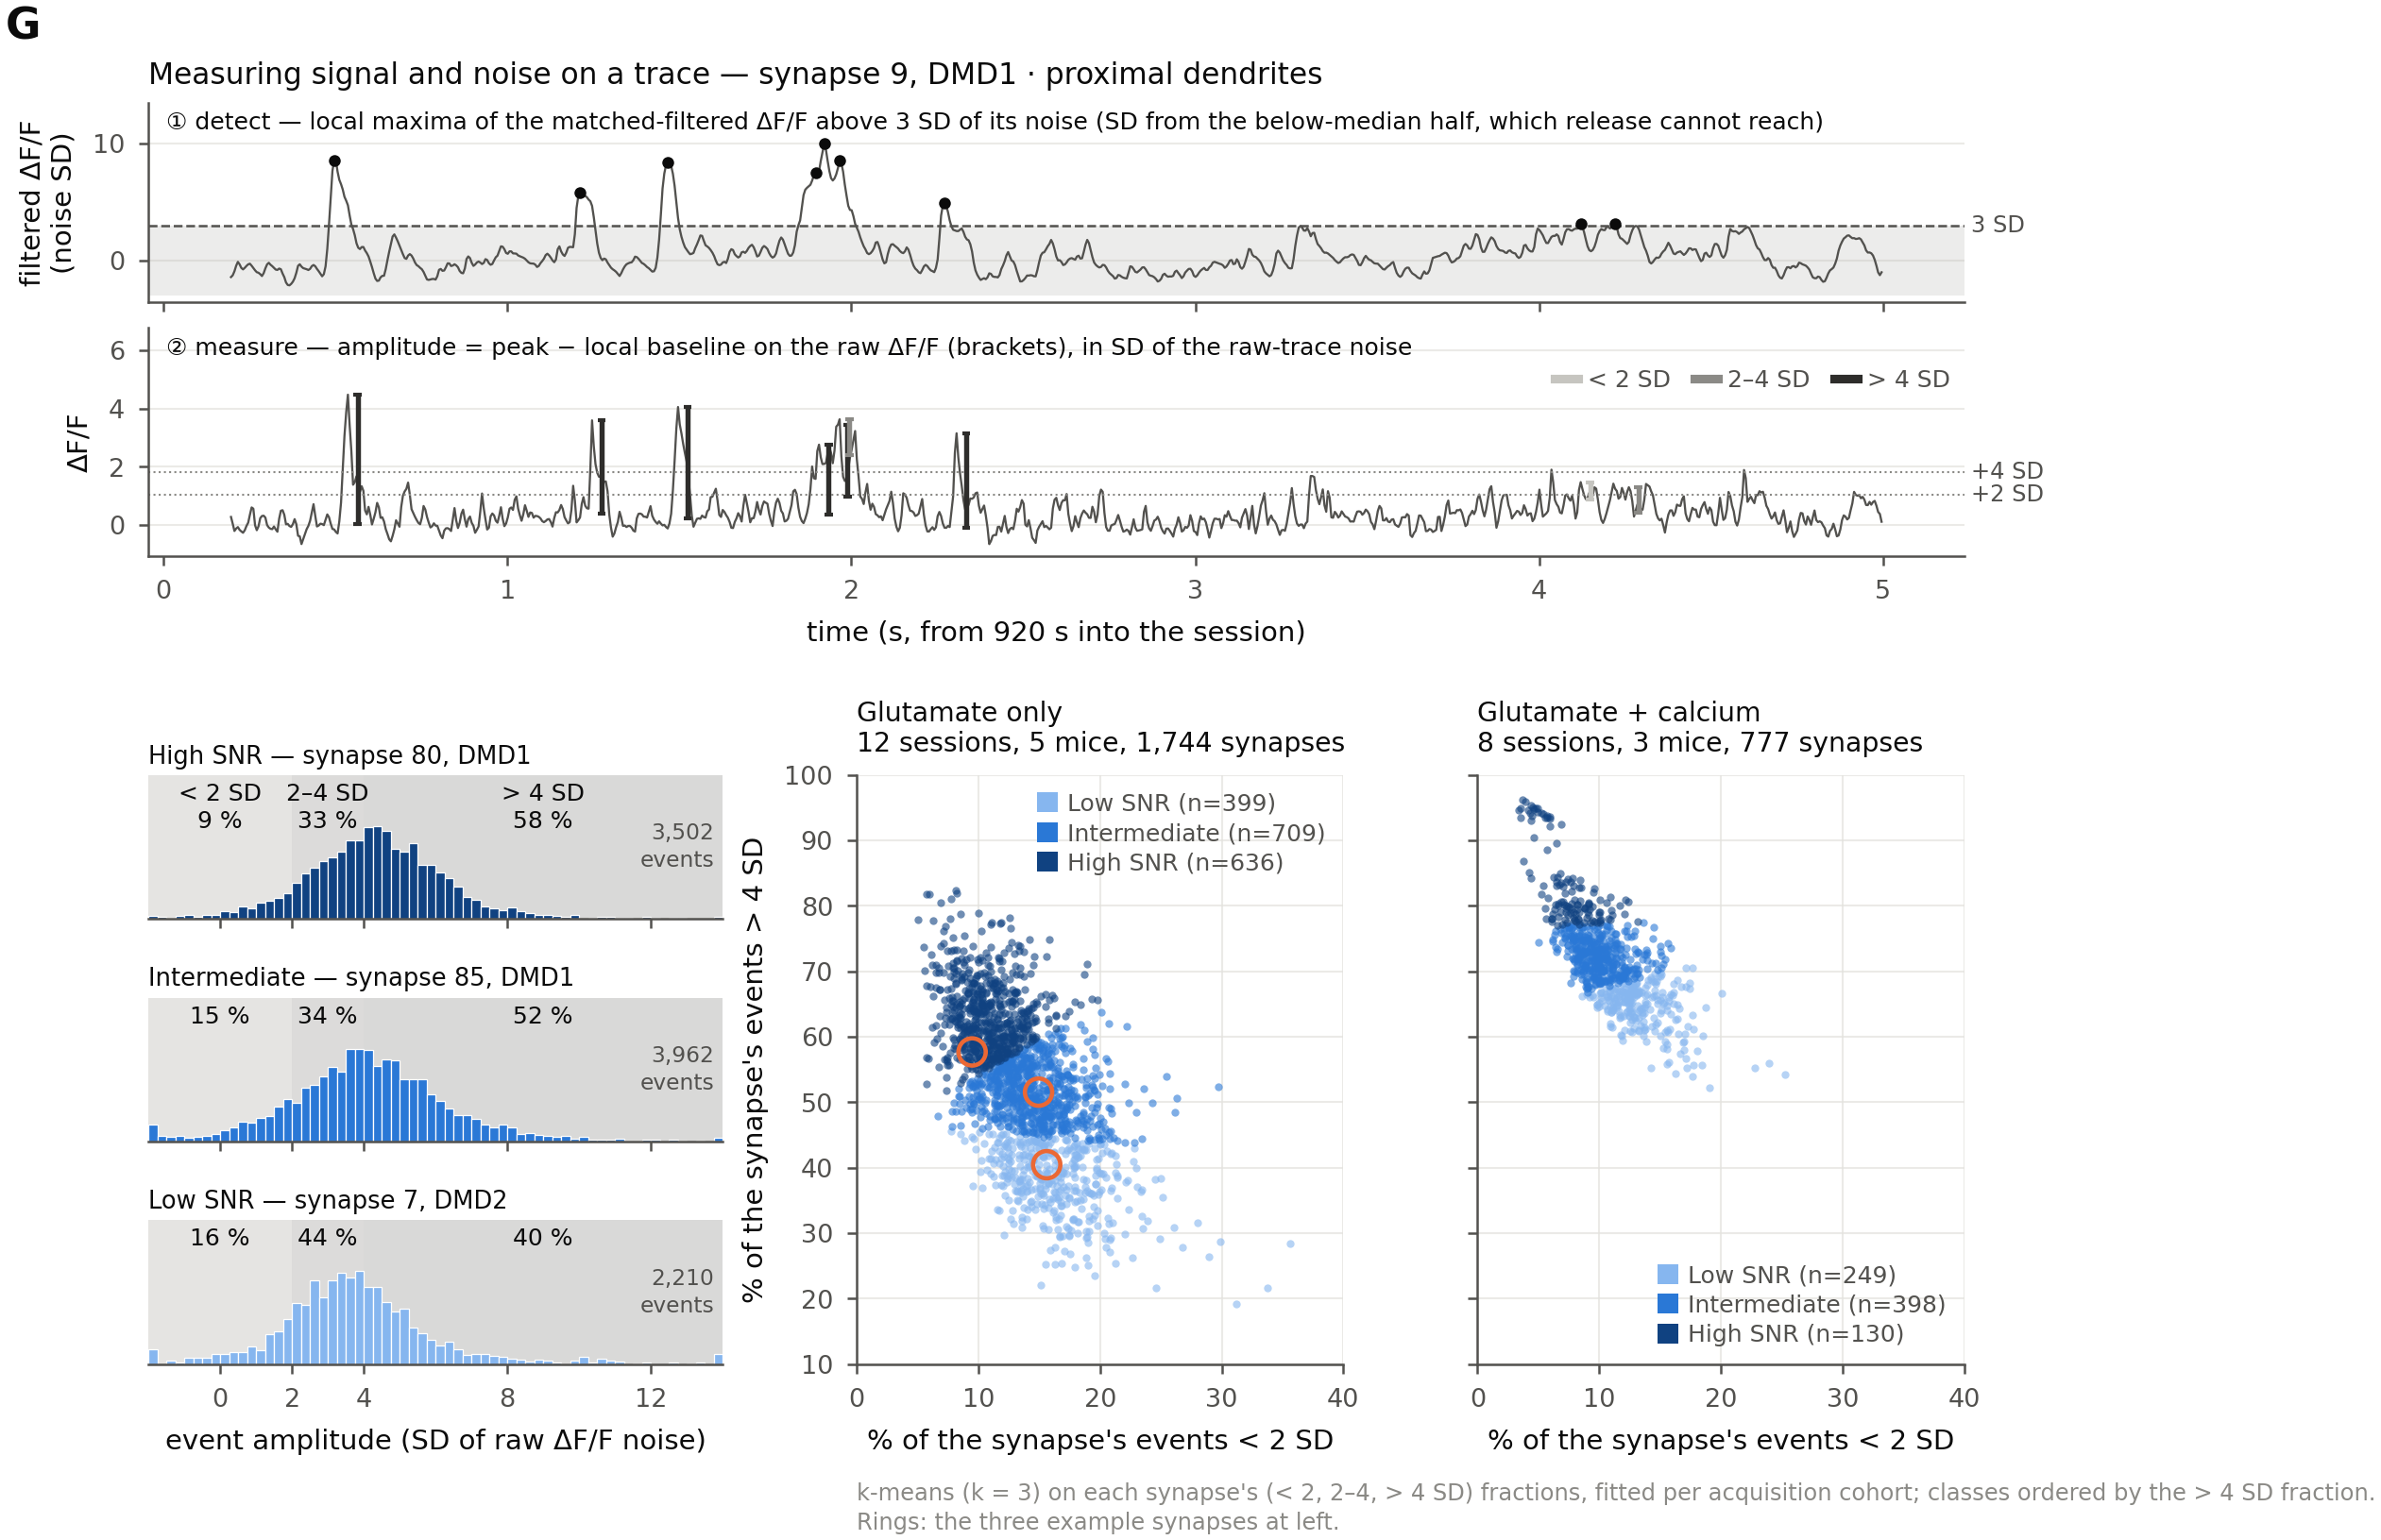

In [8]:
panels.render_panel_g(sess, m_ex, m_all, summary, OUT_DIR)
display(Image(str(OUT_DIR / "figure7_panelG_slap2_glutamate.png")))

#### Panel K — class distributions across context, compartment, and neurons

Top: event rate per synapse by stimulus context and class, pooled over all synapses of each cohort
(the glutamate-only sessions ran the standard oddball paradigm, with contexts inferred from the
orientation statistics; the glutamate + calcium sessions ship one interval table per named block).
Bottom left: class composition by dendritic compartment. Bottom right: class composition of each
neuron — one per session — in acquisition order, grouped by mouse.

panel K  → event rate (Hz/synapse) by context and class:
quality_class                     Low SNR  Intermediate  High SNR
cohort  context                                                  
glut    Blank                       0.603         0.661     0.810
        Control (random ori)        1.204         1.013     1.067
        Inter-stimulus              0.742         0.798     0.891
        Oddball deviant             1.585         1.203     1.152
        Oddball standard            0.875         0.916     1.013
        RF mapping                  0.961         0.888     1.007
glut+ca Inter-stimulus              1.168         1.175     1.893
        jitter control              1.307         1.390     1.911
        jitter oddball              1.207         1.085     1.462
        motor oddball               1.036         1.141     1.941
        movie                       1.552         1.544     2.193
        open loop prerecorded       1.235         1.380     1.939
        rf mapping 

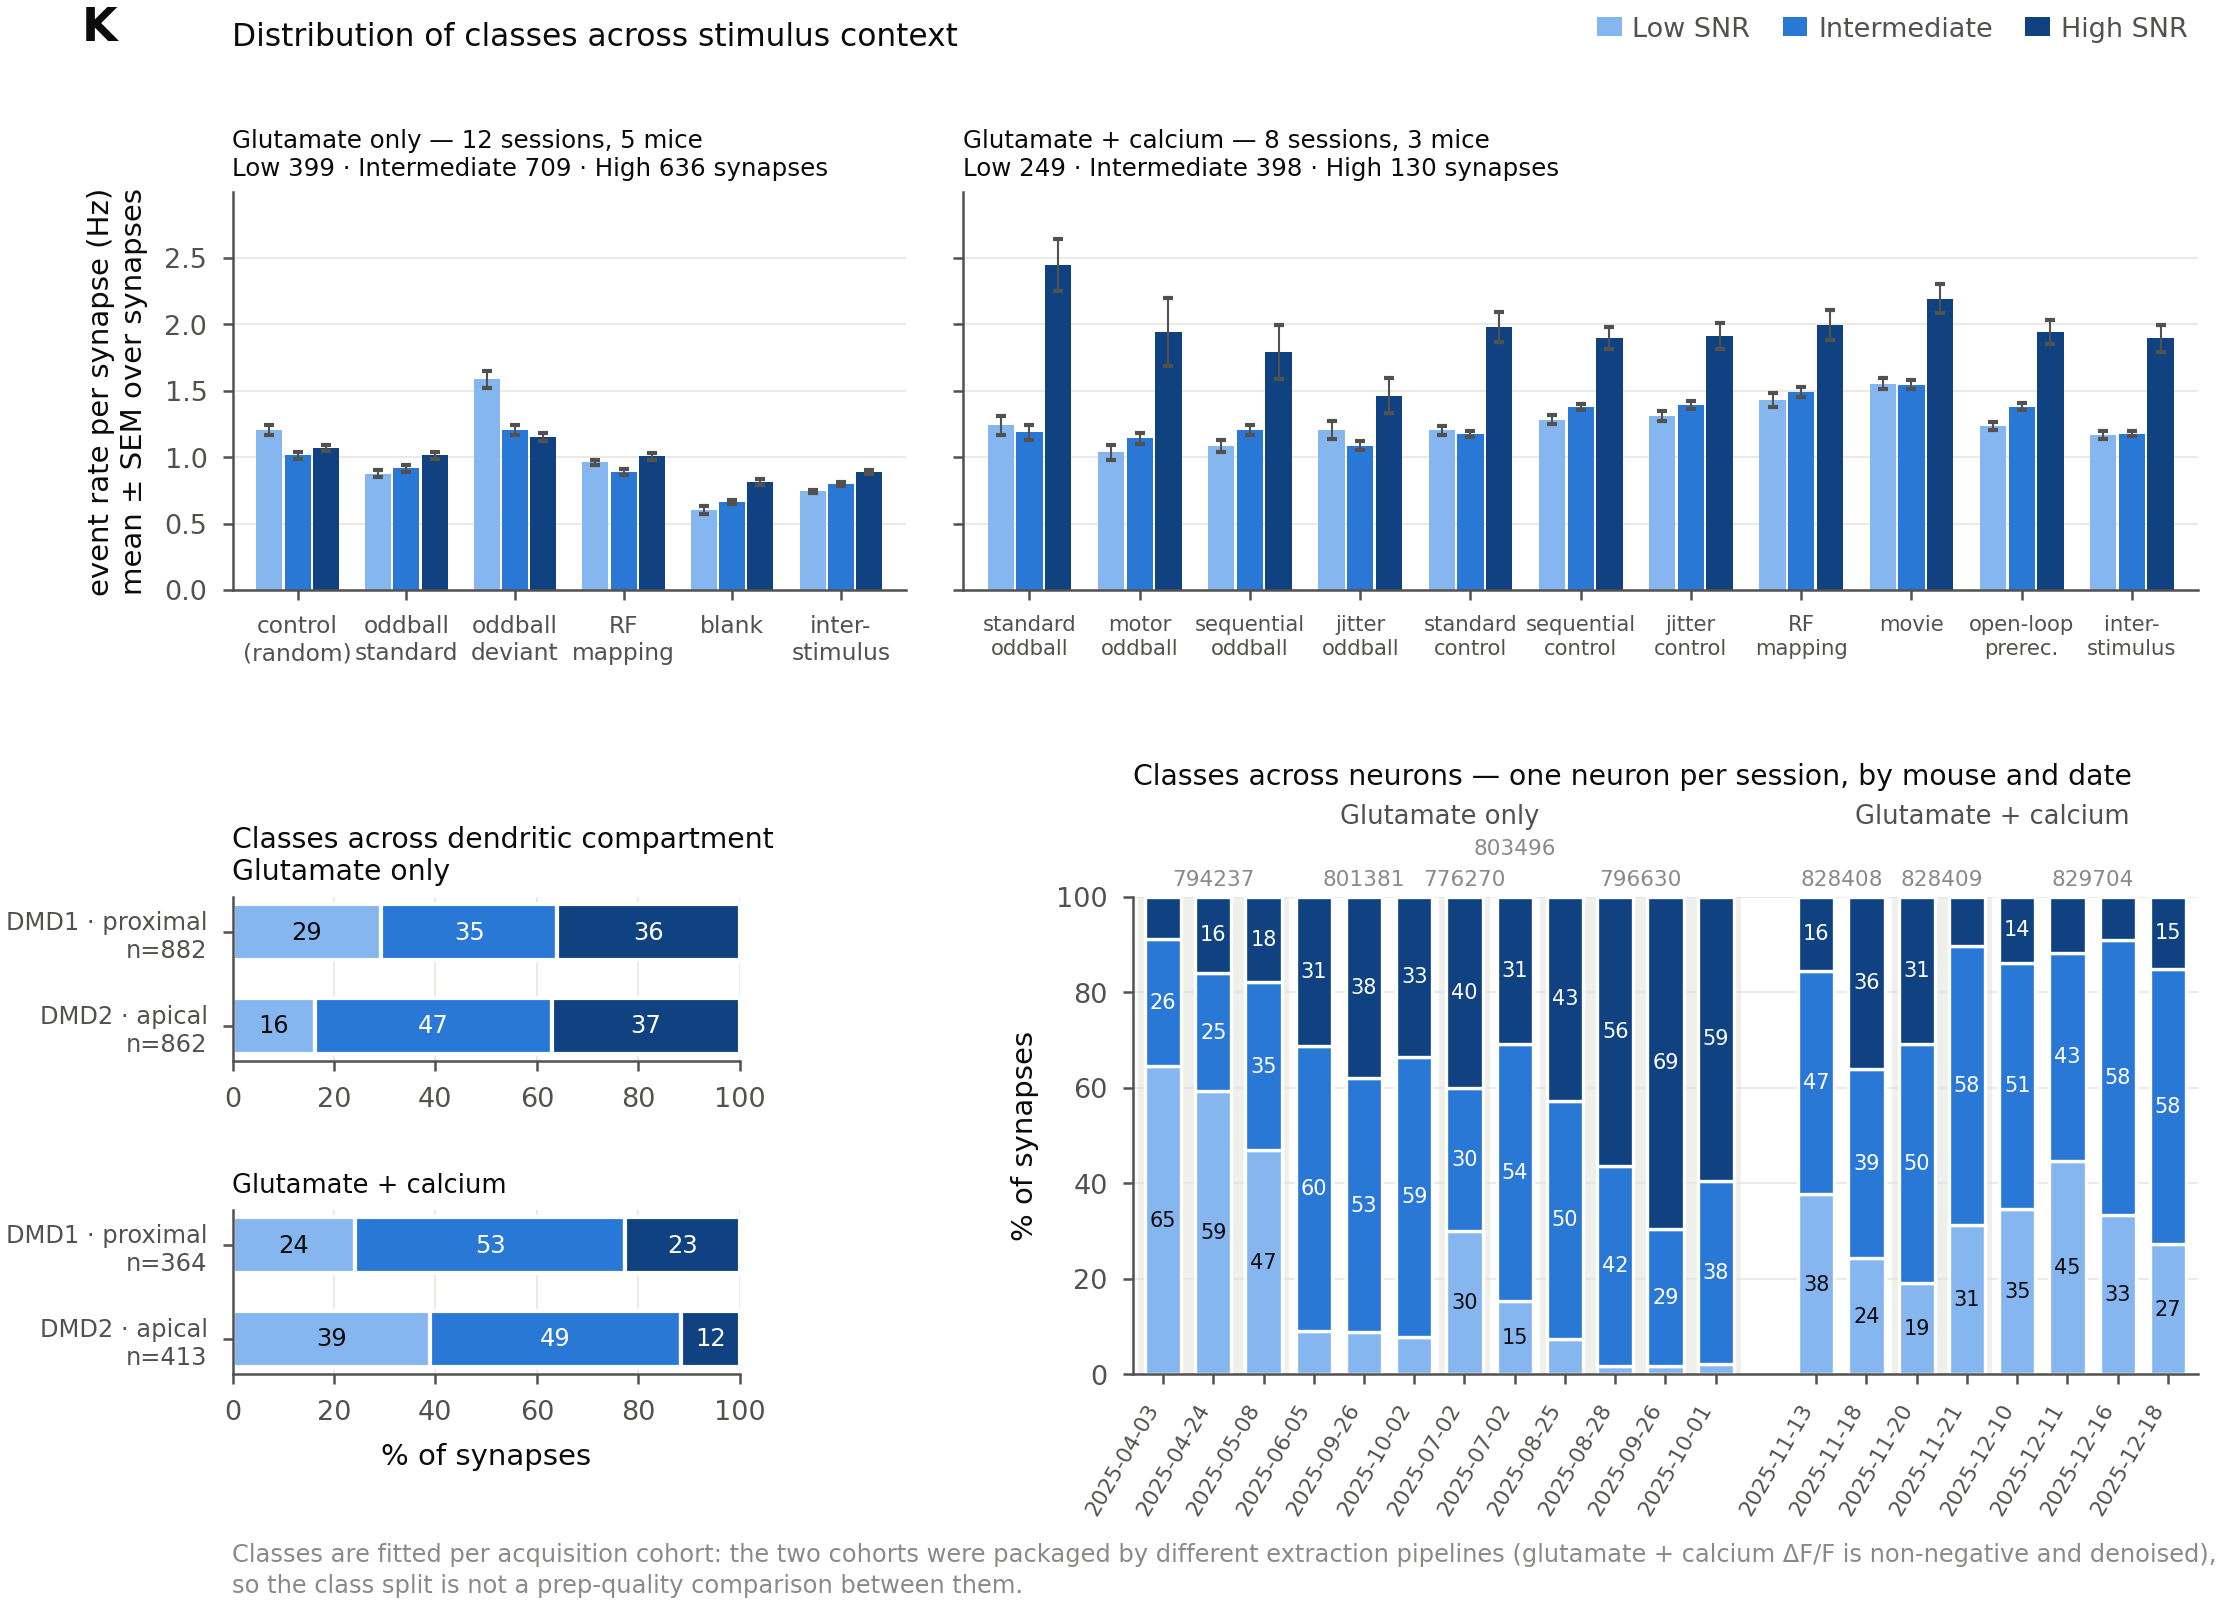

In [9]:
panels.render_panel_k(m_all, ctx_all, OUT_DIR)
display(Image(str(OUT_DIR / "figure7_panelK_slap2_glutamate.png")))

In [10]:
print("Wrote:")
for f in sorted(OUT_DIR.glob("figure7_panel*")):
    print(f"  {f}  ({f.stat().st_size/1024:.0f} KB)")

Wrote:
  plots_figure7_slap2_glutamate/figure7_panelC_slap2_glutamate.png  (446 KB)
  plots_figure7_slap2_glutamate/figure7_panelC_slap2_glutamate.svg  (384 KB)
  plots_figure7_slap2_glutamate/figure7_panelG_slap2_glutamate.png  (540 KB)
  plots_figure7_slap2_glutamate/figure7_panelG_slap2_glutamate.svg  (322 KB)
  plots_figure7_slap2_glutamate/figure7_panelK_slap2_glutamate.png  (331 KB)
  plots_figure7_slap2_glutamate/figure7_panelK_slap2_glutamate.svg  (199 KB)


## Reading the panels

**Signal quality (C, G).** The archive holds 2,540 extracted synapses over 20 sessions and 8 mice
(8.7 M detected events); 9 sources with a rectified trace (no measurable noise floor) carry no class.
In the example session, 179 synapses give ~556 k events at a median 1.04 Hz per synapse with a measured
false-positive fraction of 0.6 %. Archive-wide, the glutamate-only cohort's false-positive fraction
averages 0.3 % (90 % of synapses below 1.1 %) and is monotone in class — 1.0 % (Low), 0.15 %
(Intermediate), 0.06 % (High SNR) on average — a sanity check that the classes track signal quality.
In the glutamate + calcium cohort the fraction is 0 by construction (non-negative traces have no
downward crossings) and the 95/50 SNR is inflated for the same reason (median 3.3 vs 2.4).

**Class definition (G).** Within each cohort the classes separate along the > 4 SD fraction (medians
38 / 51 / 63 % in the glutamate-only cohort, 65 / 72 / 80 % in glutamate + calcium) while the < 2 SD
fraction falls from Low to High (16 → 11 %). Event rate barely differs between classes in the
glutamate-only cohort (medians 0.77–0.86 Hz), so the class is about event amplitude, not activity;
in the glutamate + calcium cohort the High-SNR synapses are also the most active (1.6 vs 1.2 Hz).

**Across context (K).** In the 12 standard-paradigm sessions the rate ordering is the same for every
class: oddball deviant (1.2–1.6 Hz) > control (1.0–1.2) > oddball standard ≈ RF mapping (0.9–1.0) >
inter-stimulus (0.7–0.9) > blank (0.6–0.8). Low-SNR synapses respond most to deviants and to the
random-orientation controls (1.6 and 1.2 Hz, vs 1.15 and 1.07 Hz for High SNR); the classes are closest
in the oddball-standard block. In the 8 glutamate + calcium sessions the High-SNR synapses fire
0.5–1.2 Hz faster than the other two classes in every block (most in the standard-oddball block,
2.4 vs 1.2 Hz) and the differences between blocks are modest.

**Across compartment and neurons (K).** Proximal (DMD1) and apical (DMD2) dendrites have the same
High-SNR share in the glutamate-only cohort (36 vs 37 %), and apical dendrites carry fewer Low-SNR
synapses (16 vs 29 %); in the glutamate + calcium cohort the apical plane is the poorer one (12 vs
23 % High SNR). Composition varies far more between neurons than between compartments: the High-SNR
share ranges from 9 to 69 % across sessions and is consistent within a mouse (sub-796630: 43–69 %,
sub-794237: 9–18 %, sub-829704: 9–15 %) — signal quality is largely a per-animal property.

Caveats worth repeating with these numbers: the glutamate-only stimulus contexts are inferred from the
orientation statistics of a single presentation table (the glutamate + calcium sessions ship named
block tables); and the two cohorts were packaged by different extraction pipelines, so classes are fitted
per cohort and the cohort difference is not a prep-quality comparison.
